# Instagram Profile Analysis — Dewii

Analýza kódovaných dat z Instagram profilových fotografií.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ── Kódovník ──────────────────────────────────────────────────────────────────
labels = {
    'počet_osob': {1: 'Jedna', 2: 'Více', 3: 'Žádná'},
    'osoba_na_fotografii': {1: 'Autorka (Dewii)', 2: 'Autorka + někdo', 3: 'Někdo jiný', 4: 'Bez lidí'},
    'typ_obsahu': {1: 'Portrét', 2: 'Skupinová foto', 3: 'Cestování',
                   4: 'Aktivistické sdělení', 5: 'Reklama', 6: 'Sportovní aktivita', 7: 'Jídlo'},
    'prostředí': {1: 'Domácí interiér', 2: 'Příroda', 3: 'Veřejný prostor venku',
                  4: 'Veřejný prostor uvnitř', 5: 'Kulturní událost',
                  6: 'Nelze určit', 7: 'Soukromý pozemek venku'},
    'póza_osoby': {1: 'Osoba není přítomna', 2: 'Pohled do kamery', 3: 'Pohled mimo kameru',
                   4: 'Speciální póza', 5: 'Spontánní fotografie', 6: 'Rozdílné pózy', 7: 'Zezadu'},
    'úhel_kamery': {1: 'Podhled', 2: 'Přímý', 3: 'Nadhled'},
    'typ_fotografie': {1: 'Selfie', 2: 'Profesionální', 3: 'Neprofesionální', 4: 'Momentka'},
    'kompozice': {1: 'Detail', 2: 'Polocelek', 3: 'Celek'},
}

# ── Load from Excel ───────────────────────────────────────────────────────────
raw = pd.read_excel('analysis.xlsx', sheet_name='Sheet1')
data_rows = raw[pd.to_numeric(raw['Variables'], errors='coerce').notna()].copy()
data_rows = data_rows[['Variables', 'počet osob', 'osoba na fotografii', 'typ obsahu',
                        'prostředí', 'póza osoby', 'úhel kamery', 'Typ fotografie',
                        'kompozice', 'počet likes']].copy()
data_rows.columns = ['foto_id', 'počet_osob', 'osoba_na_fotografii', 'typ_obsahu',
                     'prostředí', 'póza_osoby', 'úhel_kamery', 'typ_fotografie',
                     'kompozice', 'likes']
data_rows = data_rows.reset_index(drop=True)
data_rows['foto_id'] = data_rows['foto_id'].astype(int)
data_rows = data_rows.set_index('foto_id')

cat_cols = list(labels.keys())
data_rows[cat_cols] = data_rows[cat_cols].astype(int)

# Strip thousands separators (e.g. '11 200' → 11200) then cast
data_rows['likes'] = (
    data_rows['likes'].astype(str).str.replace(r'\s', '', regex=True).astype(int)
)

df = data_rows

# Decoded text version for readable plots
df_text = df.copy()
for col, mapping in labels.items():
    df_text[col] = df[col].map(mapping)

print(f'Načteno {len(df)} fotografií')
print(df_text.head())

Načteno 100 fotografií
        počet_osob osoba_na_fotografii            typ_obsahu  \
foto_id                                                        
1            Jedna     Autorka (Dewii)  Aktivistické sdělení   
2             Více     Autorka + někdo        Skupinová foto   
3            Jedna     Autorka (Dewii)               Portrét   
4            Jedna     Autorka (Dewii)    Sportovní aktivita   
5            Jedna     Autorka (Dewii)               Portrét   

                     prostředí          póza_osoby úhel_kamery typ_fotografie  \
foto_id                                                                         
1                      Příroda  Pohled mimo kameru     Podhled         Selfie   
2        Veřejný prostor venku      Speciální póza     Podhled       Momentka   
3                      Příroda    Pohled do kamery     Nadhled  Profesionální   
4                      Příroda  Pohled mimo kameru     Nadhled       Momentka   
5                      Příroda    Pohled d

## 1. Koláčové grafy — rozložení kategorií

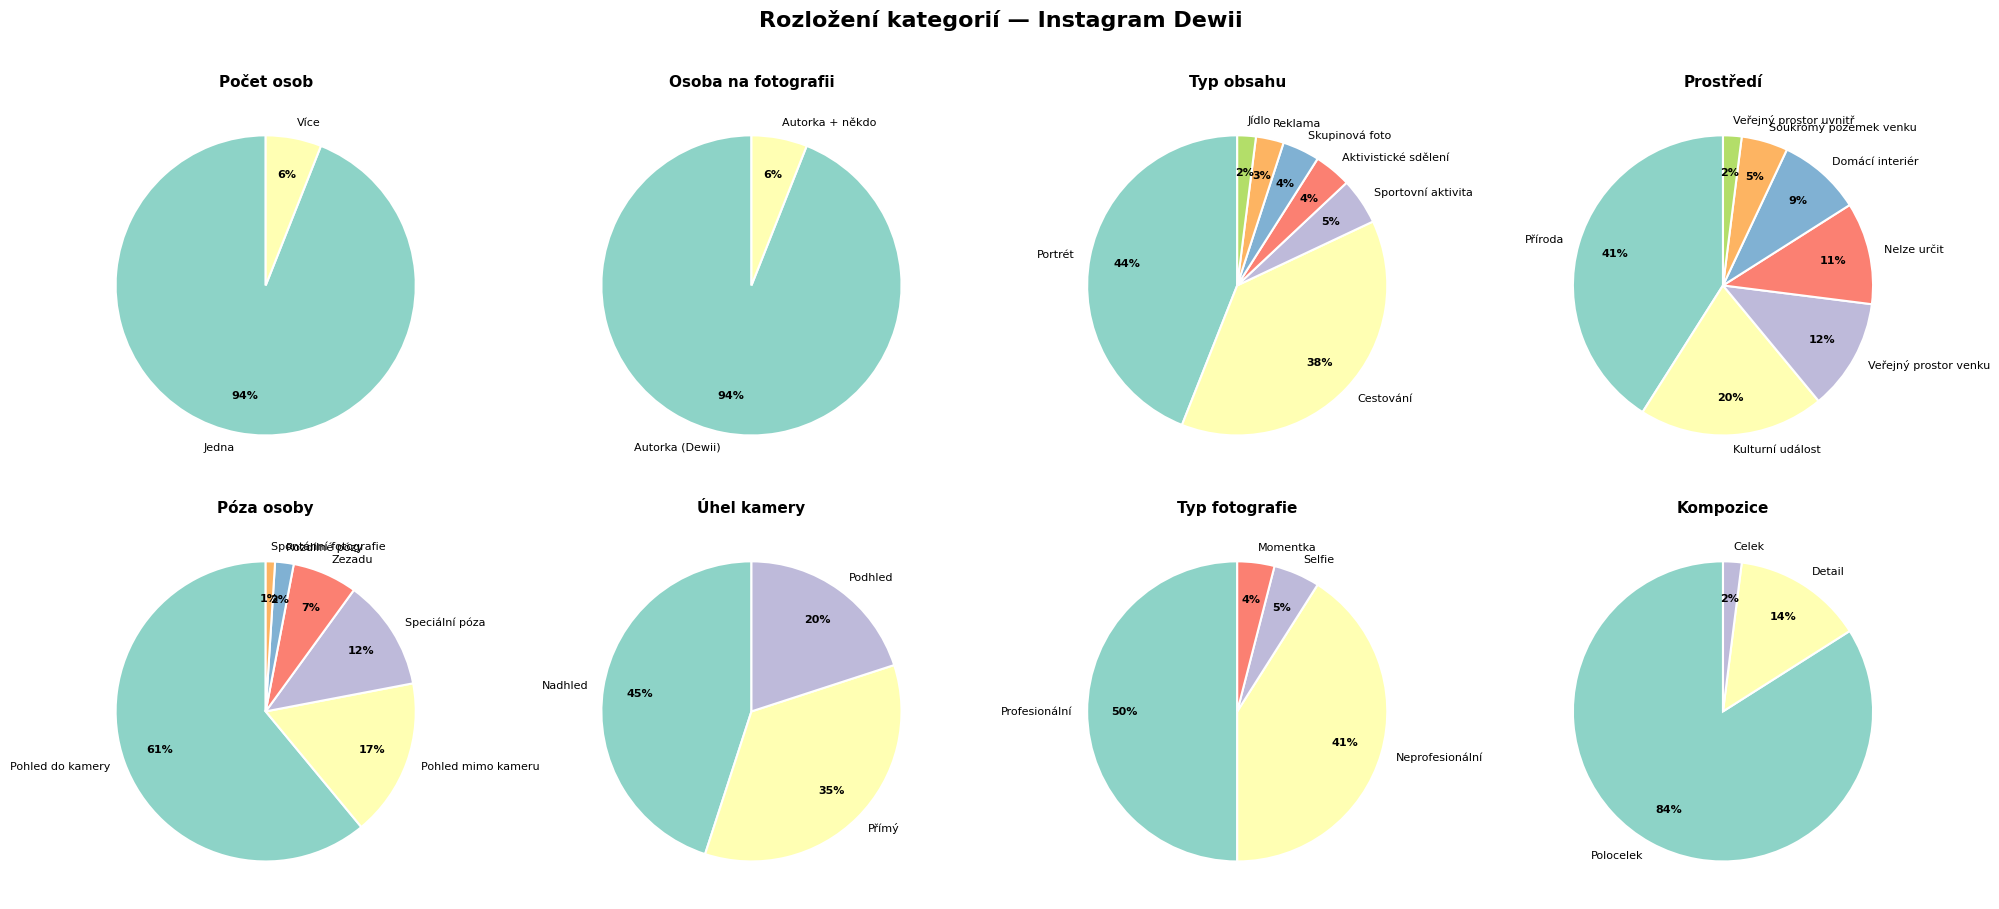

In [4]:
titles_cs = {
    'počet_osob':           'Počet osob',
    'osoba_na_fotografii':  'Osoba na fotografii',
    'typ_obsahu':           'Typ obsahu',
    'prostředí':            'Prostředí',
    'póza_osoby':           'Póza osoby',
    'úhel_kamery':          'Úhel kamery',
    'typ_fotografie':       'Typ fotografie',
    'kompozice':            'Kompozice',
}

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('Rozložení kategorií — Instagram Dewii', fontsize=16, fontweight='bold', y=1.01)

palette = plt.cm.Set3.colors

for ax, col in zip(axes.flat, cat_cols):
    counts = df_text[col].value_counts()
    wedge_colors = palette[:len(counts)]
    wedges, texts, autotexts = ax.pie(
        counts,
        labels=counts.index,
        autopct='%1.0f%%',
        startangle=90,
        colors=wedge_colors,
        pctdistance=0.75,
        wedgeprops=dict(edgecolor='white', linewidth=1.5)
    )
    for t in texts:
        t.set_fontsize(8)
    for at in autotexts:
        at.set_fontsize(8)
        at.set_fontweight('bold')
    ax.set_title(titles_cs[col], fontsize=11, fontweight='bold', pad=8)

plt.tight_layout()
plt.savefig('pie_categories.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Donut grafy — typ obsahu a typ fotografie (zvýrazněné)

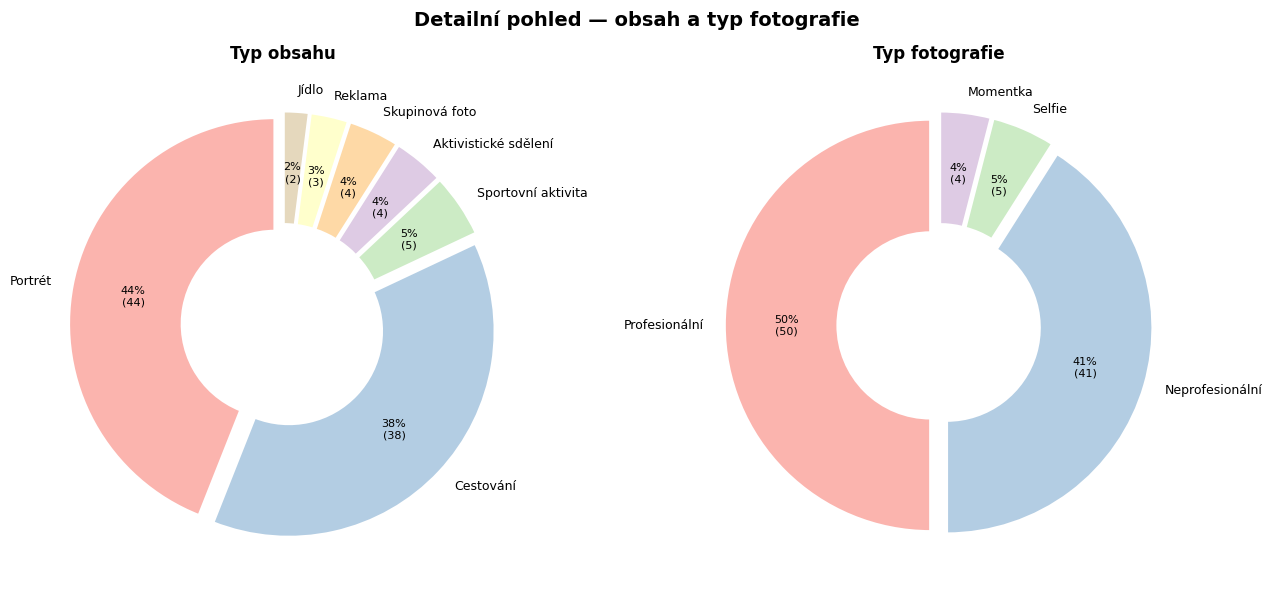

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle('Detailní pohled — obsah a typ fotografie', fontsize=14, fontweight='bold')

for ax, col in zip(axes, ['typ_obsahu', 'typ_fotografie']):
    counts = df_text[col].value_counts()
    explode = [0.04] * len(counts)
    wedges, texts, autotexts = ax.pie(
        counts,
        labels=counts.index,
        autopct=lambda p: f'{p:.0f}%\n({int(round(p*len(df)/100))})',
        startangle=90,
        explode=explode,
        colors=plt.cm.Pastel1.colors[:len(counts)],
        pctdistance=0.70,
        wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2)  # donut
    )
    for t in texts:
        t.set_fontsize(9)
    for at in autotexts:
        at.set_fontsize(8)
    ax.set_title(titles_cs[col], fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('donut_content_type.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Průměrné likes podle kategorie

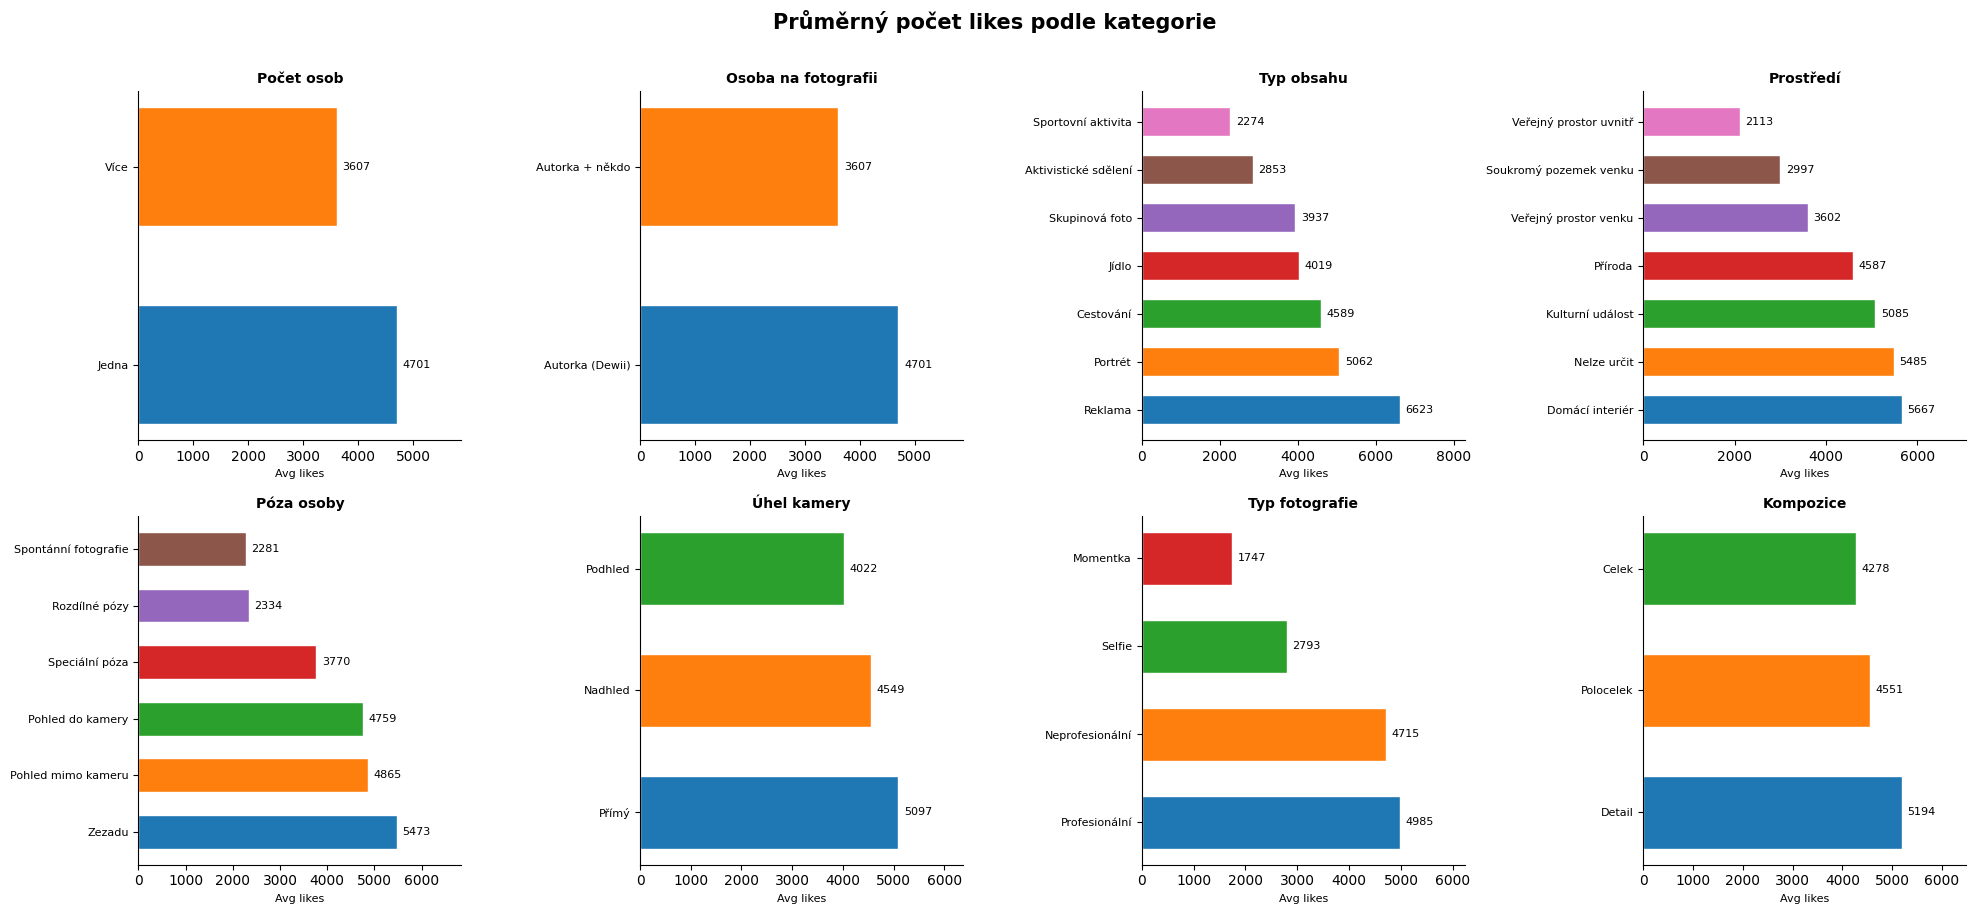

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('Průměrný počet likes podle kategorie', fontsize=15, fontweight='bold', y=1.01)

bar_colors = plt.cm.tab10.colors

for ax, col in zip(axes.flat, cat_cols):
    avg = df_text.groupby(col)['likes'].mean().sort_values(ascending=False)
    bars = ax.barh(avg.index, avg.values, color=bar_colors[:len(avg)],
                   edgecolor='white', height=0.6)
    ax.bar_label(bars, fmt='%.0f', padding=4, fontsize=8)
    ax.set_title(titles_cs[col], fontsize=10, fontweight='bold')
    ax.set_xlabel('Avg likes', fontsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlim(0, avg.values.max() * 1.25)

plt.tight_layout()
plt.savefig('avg_likes_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Distribuce likes — histogram + boxplot

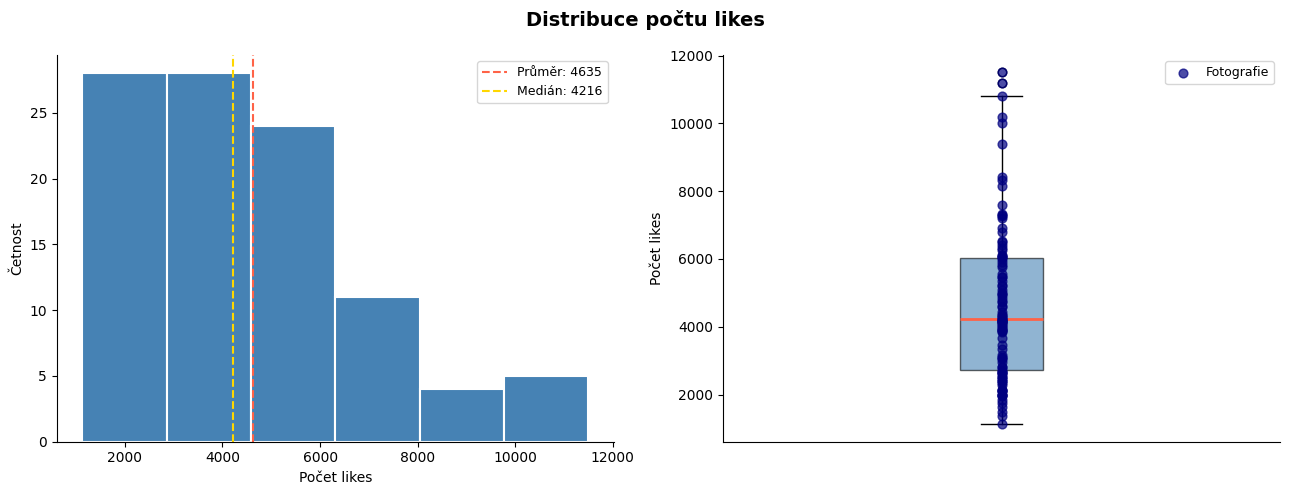

count      100.0
mean      4635.3
std       2304.9
min       1126.0
25%       2710.0
50%       4215.5
75%       6015.2
max      11500.0
Name: likes, dtype: float64


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribuce počtu likes', fontsize=14, fontweight='bold')

# Histogram
ax1.hist(df['likes'], bins=6, color='steelblue', edgecolor='white', linewidth=1.5)
ax1.axvline(df['likes'].mean(), color='tomato', linestyle='--', linewidth=1.5,
            label=f'Průměr: {df["likes"].mean():.0f}')
ax1.axvline(df['likes'].median(), color='gold', linestyle='--', linewidth=1.5,
            label=f'Medián: {df["likes"].median():.0f}')
ax1.set_xlabel('Počet likes')
ax1.set_ylabel('Četnost')
ax1.legend(fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)

# Boxplot
bp = ax2.boxplot(df['likes'], patch_artist=True, notch=False, vert=True,
                 boxprops=dict(facecolor='steelblue', alpha=0.6),
                 medianprops=dict(color='tomato', linewidth=2))
ax2.scatter([1]*len(df), df['likes'], color='navy', s=40, zorder=3, alpha=0.7, label='Fotografie')
ax2.set_ylabel('Počet likes')
ax2.set_xticks([])
ax2.legend(fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('likes_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(df['likes'].describe().round(1))

## 5. Radar / spider chart — profil průměrných hodnot kódů

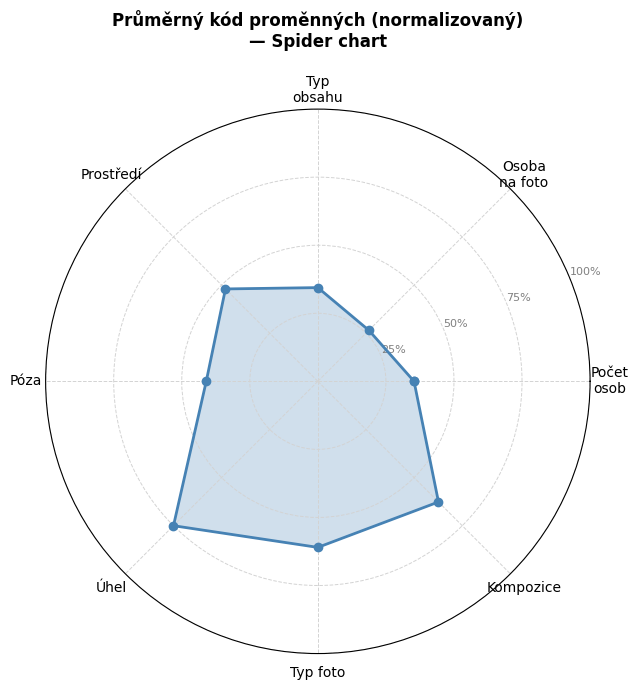

In [8]:
# Spider chart: average coded value per variable (normalized 0-1)
variables = cat_cols
max_vals = {col: max(labels[col].keys()) for col in variables}
avg_norm = [df[col].mean() / max_vals[col] for col in variables]
labels_short = ['Počet\nosob', 'Osoba\nna foto', 'Typ\nobsahu', 'Prostředí',
                'Póza', 'Úhel', 'Typ foto', 'Kompozice']

N = len(variables)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
avg_norm += avg_norm[:1]   # close the polygon
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.plot(angles, avg_norm, 'o-', linewidth=2, color='steelblue')
ax.fill(angles, avg_norm, alpha=0.25, color='steelblue')
ax.set_thetagrids(np.degrees(angles[:-1]), labels_short, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=8, color='grey')
ax.set_title('Průměrný kód proměnných (normalizovaný)\n— Spider chart', fontsize=12, fontweight='bold', pad=20)
ax.grid(color='lightgrey', linestyle='--', linewidth=0.7)

plt.tight_layout()
plt.savefig('spider_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Heatmapa korelací (kódované hodnoty + likes)

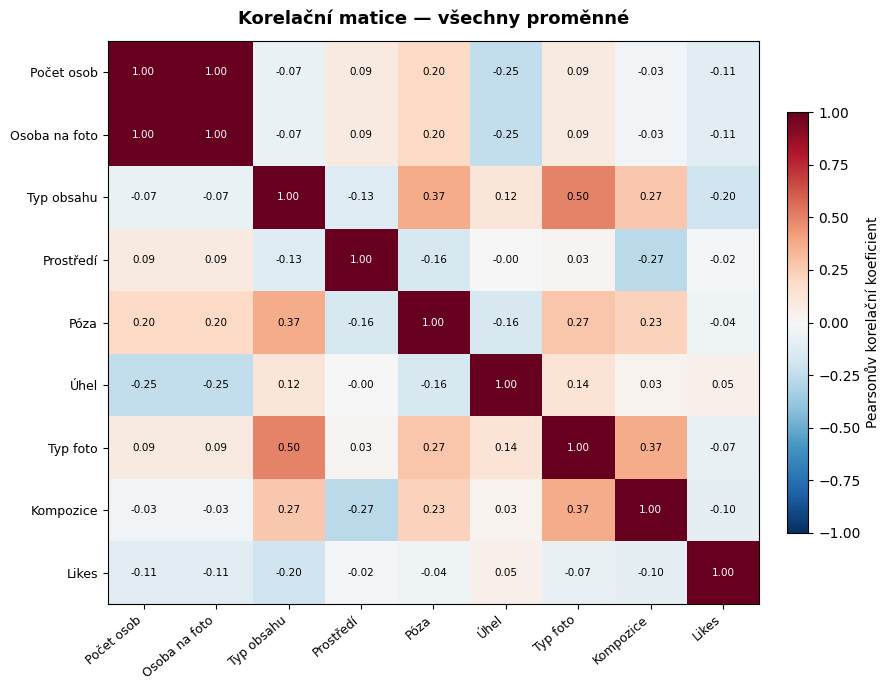

In [9]:
import matplotlib.colors as mcolors

corr = df.corr(numeric_only=True)
short_names = ['Počet osob', 'Osoba na foto', 'Typ obsahu', 'Prostředí',
               'Póza', 'Úhel', 'Typ foto', 'Kompozice', 'Likes']
corr.index = short_names
corr.columns = short_names

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04, label='Pearsonův korelační koeficient')

ax.set_xticks(range(len(short_names)))
ax.set_yticks(range(len(short_names)))
ax.set_xticklabels(short_names, rotation=40, ha='right', fontsize=9)
ax.set_yticklabels(short_names, fontsize=9)

for i in range(len(short_names)):
    for j in range(len(short_names)):
        val = corr.iloc[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7.5, color=color)

ax.set_title('Korelační matice — všechny proměnné', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()